In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_dsa = pd.read_csv('dataset.csv')

In [3]:
df_dsa.shape

(400, 7)

In [4]:
df_dsa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   valor_venda_unitario  400 non-null    float64
 1   valor_venda_total     400 non-null    int64  
 2   custo_entrega         400 non-null    int64  
 3   status_entrega        400 non-null    object 
 4   idade_vendedor        400 non-null    int64  
 5   area_urbana           400 non-null    object 
 6   cliente_local         400 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 22.0+ KB


In [5]:
df_dsa.head()

,valor_venda_unitario,valor_venda_total,custo_entrega,status_entrega,idade_vendedor,area_urbana,cliente_local
0,9.50,138,11,Ruim,42,Sim,Sim
1,11.22,111,16,Bom,65,Sim,Sim
2,10.06,113,10,Medio,59,Sim,Sim
3,7.40,117,4,Medio,55,Sim,Sim
4,4.15,141,3,Ruim,38,Sim,Nao


### Análise exploratoria de acordo com o tipo de variavel

In [6]:
# Configuração de estilo
sns.set(style="darkgrid")

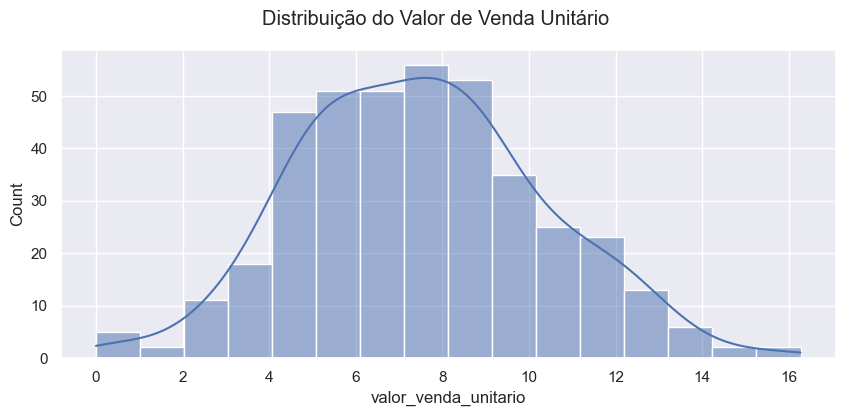

In [7]:
# Plot de valor_venda_unitario
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição do Valor de Venda Unitário')
sns.histplot(df_dsa['valor_venda_unitario'], kde = True);

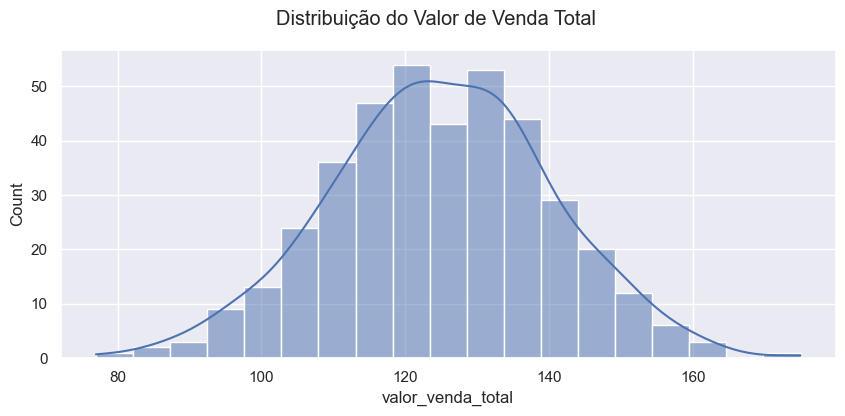

In [8]:
# Plot de valor_venda_total
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição do Valor de Venda Total')
sns.histplot(df_dsa['valor_venda_total'], kde = True);

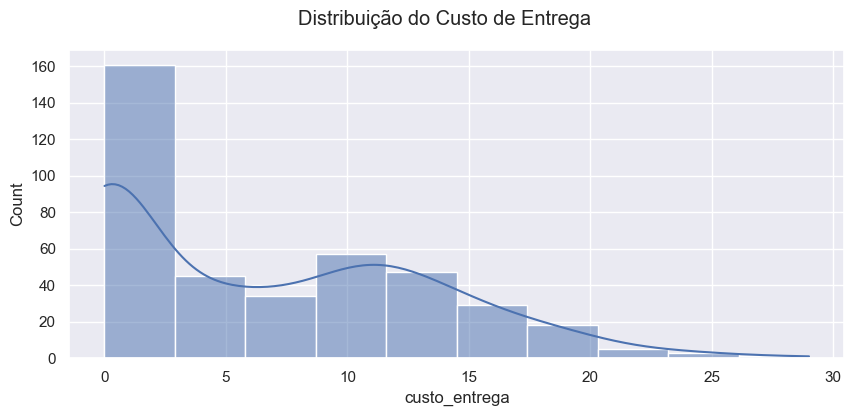

In [9]:
# Plot de custo_entrega
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição do Custo de Entrega')
sns.histplot(df_dsa['custo_entrega'], kde = True);

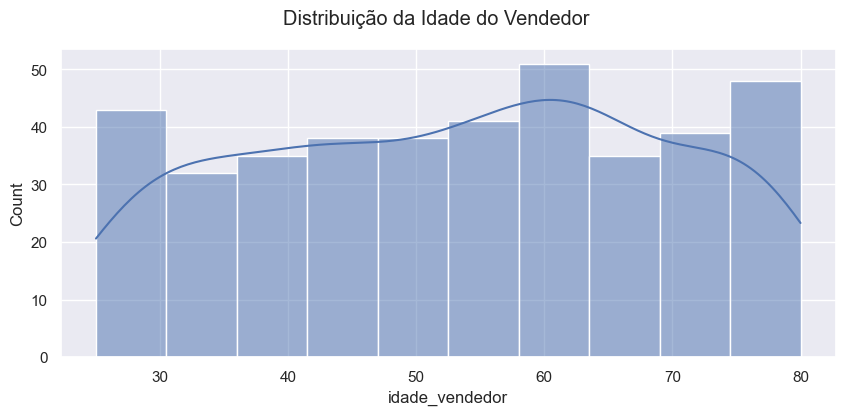

In [10]:
# Plot de idade_vendedor
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição da Idade do Vendedor')
sns.histplot(df_dsa['idade_vendedor'], kde = True);

In [11]:
# Configuração de estilo
sns.set(style="whitegrid")

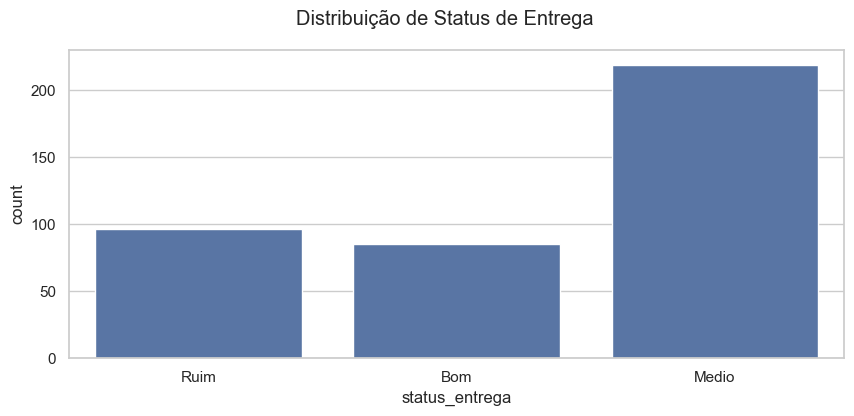

In [12]:
# Plot de status_entrega
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição de Status de Entrega')
sns.countplot(data = df_dsa, x = 'status_entrega');

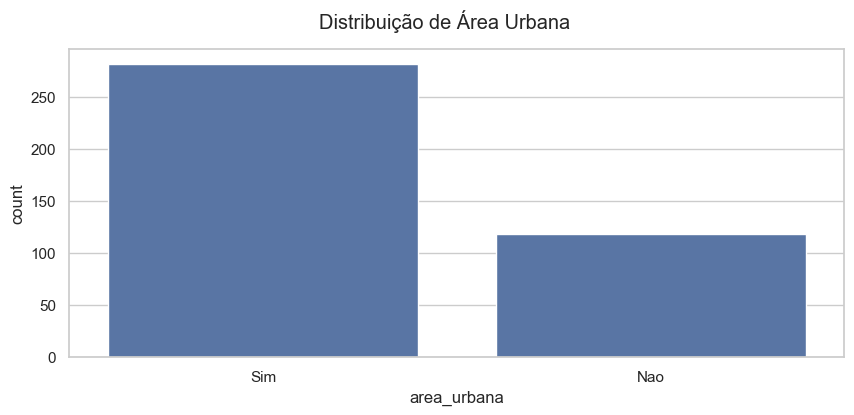

In [13]:
# Plot de area_urbana
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição de Área Urbana')
sns.countplot(data = df_dsa, x = 'area_urbana');

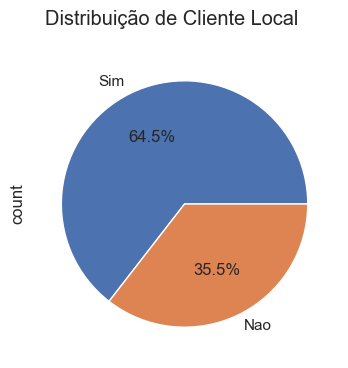

In [14]:
# Plot de cliente_local
fig, axes = plt.subplots(1, 1, figsize = (10, 4))
fig.suptitle('Distribuição de Cliente Local')
df_dsa['cliente_local'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%');

### Criando e analisando a tabela de contingência em py

In [15]:
# Cria a tabela de contingencia
conting_status_area = pd.crosstab(df_dsa['status_entrega'], df_dsa['area_urbana'])

In [16]:
conting_status_area

area_urbana,Nao,Sim
status_entrega,,
Bom,28,57
Medio,68,151
Ruim,22,74


### Utilizando a estratégia n1, OneHotEnconder

In [17]:
#selecionando as variáveis independentes (x) e (y)

"""
Aqui estamos isolando justamente a variável que queremos prever
"""

X = df_dsa.drop('custo_entrega', axis = 1)
y = df_dsa['custo_entrega']

In [18]:
# separando as variáveis categóritcas e númericas, pois terão processamentos diferentes

categorical_features = ['status_entrega', 'area_urbana', 'cliente_local']
numerical_features = ['valor_venda_unitario', 'valor_venda_total', 'idade_vendedor']

In [19]:
# criando o transformador para variáveis categóricas
categorical_transformer = OneHotEncoder(drop = 'first')

In [20]:
# cria o transformador para variávis numéricas
numerical_transformer = StandardScaler()

In [21]:
#combinando os transformadores
#pré processamento: codificação one-hot para variáveis categóricas e padronização para númericas

preprocessor_v1 = ColumnTransformer(
    transformers = [
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [22]:
#criando o pipeline com p processamento e com o modelo
modelo_dsa_v1 = Pipeline(steps = [('preprocessor', preprocessor_v1), ('regressor', LinearRegression())])

### Impacto da estratégia 1 na modelagem preditiva

In [23]:
# dividindo os dados em treino e teste

"""
o test_size é a proporção que será utilizada para os dados de teste. nesse caso, 0.2 = 20%
"""


X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [24]:
# Fit somente com os dados de treino
modelo_dsa_v1.fit(X_treino, y_treino)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['valor_venda_unitario',
                                                   'valor_venda_total',
                                                   'idade_vendedor']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['status_entrega',
                                                   'area_urbana',
                                                   'cliente_local'])])),
                ('regressor', LinearRegression())])

In [25]:
#usamos pedict nos dados de teste
y_pred = modelo_dsa_v1.predict(X_teste)

In [26]:
#avaliando o modelo

rmse_v1 = np.sqrt(mean_squared_error(y_teste, y_pred))
r2_v1 = r2_score(y_teste, y_pred) #maior possível

In [27]:
print(rmse_v1)

5.099017184556865


In [28]:
print(r2_v1)

0.42181922803831906


### estratégia 2 

In [29]:
# separa as variáveis categóritcas (nominais e ordinais e númericas, pois terão processamentos diferentes)

categorical_features_nominal = ['area_urbana', 'cliente_local']
categorical_features_ordinal = ['status_entrega']
numerical_features = ['valor_venda_unitario', 'valor_venda_total', 'idade_vendedor']

In [30]:
# transforma para as variáveis categóricas ordinais
categorical_transformer_ordinal = OrdinalEncoder()

In [31]:
# transforma para as variaveis categóricas nominais
categorical_transformer_nominal = OneHotEncoder(drop = 'first')

In [32]:
# CRIA O TRANSFORMADOR PARA AS VARIAVEIS NUMERICAS
numerical_transformer = StandardScaler()

In [33]:
# combinando os transformadores
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat_nomminal', categorical_transformer_nominal, categorical_features_nominal),
        ('cat_ordinal', categorical_transformer_ordinal, categorical_features_ordinal)
    
        ])

In [34]:
#criando o pipeline com p processamento e com o modelo
modelo_dsa_v2 = Pipeline(steps = [('preprocessor', preprocessor_v2), ('regressor', LinearRegression())])

### Impacto da estratégia 2 na modelagem predtiva


In [35]:
# Fit somente com os dados de treino
modelo_dsa_v2.fit(X_treino, y_treino)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['valor_venda_unitario',
                                                   'valor_venda_total',
                                                   'idade_vendedor']),
                                                 ('cat_nomminal',
                                                  OneHotEncoder(drop='first'),
                                                  ['area_urbana',
                                                   'cliente_local']),
                                                 ('cat_ordinal',
                                                  OrdinalEncoder(),
                                                  ['status_entrega'])])),
                ('regressor', LinearRegression())])

In [36]:
#usamos pedict nos dados de teste
y_pred_v2 = modelo_dsa_v2.predict(X_teste)

In [37]:

rmse_v2 = np.sqrt(mean_squared_error(y_teste, y_pred_v2))
r2_v2 = r2_score(y_teste, y_pred_v2) #maior possível

In [38]:
print(rmse_v2)

5.123545938744093


In [39]:
print(r2_v2)

0.41624318669246607


## Interpretando a Relação das Variáveis Preditoras com a Variável Alvo

In [40]:
# Para extrair os coeficientes, precisamos acessar o regressor dentro do pipeline...
model_regressor = modelo_dsa_v1.named_steps['regressor']

In [41]:
# ... e também tratar a transformação One-Hot para obter os nomes das variáveis
atrib_cat = modelo_dsa_v1.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)

In [42]:
atrib_cat

array(['status_entrega_Medio', 'status_entrega_Ruim', 'area_urbana_Sim',
       'cliente_local_Sim'], dtype=object)

In [43]:
# Combinando os nomes das variáveis numéricas e categóricas transformadas
nomes_todos_atributos = numerical_features + list(atrib_cat)

In [44]:
nomes_todos_atributos

['valor_venda_unitario',
 'valor_venda_total',
 'idade_vendedor',
 'status_entrega_Medio',
 'status_entrega_Ruim',
 'area_urbana_Sim',
 'cliente_local_Sim']

In [45]:
# Coeficientes do modelo
coeficientes = model_regressor.coef_

In [46]:
coeficientes

array([ 1.5759904 , -0.17500897,  0.36883283,  1.33280247,  1.70116209,
       -0.36918643,  9.04891871])

In [47]:
# Criando um DataFrame para melhor visualização
dsa_coef_df = pd.DataFrame({'Atributo': nomes_todos_atributos, 'Coeficiente': coeficientes})

In [48]:
# Ordenando os coeficientes por magnitude (valor absoluto)
dsa_coef_df = dsa_coef_df.reindex(dsa_coef_df.Coeficiente.abs().sort_values(ascending = False).index)

In [49]:
dsa_coef_df

,Atributo,Coeficiente
6,cliente_local_Sim,9.048919
4,status_entrega_Ruim,1.701162
0,valor_venda_unitario,1.575990
3,status_entrega_Medio,1.332802
5,area_urbana_Sim,-0.369186
2,idade_vendedor,0.368833
1,valor_venda_total,-0.175009


A interpretação dos coeficientes em um modelo de regressão linear fornece insights sobre como cada variável preditora (ou "feature") influencia a variável alvo, assumindo que todas as outras variáveis no modelo permanecem constantes. Aqui está uma interpretação detalhada dos coeficientes fornecidos:

**cliente_local_Sim (9.048919)**: Quando o cliente é local (Sim), espera-se, em média, um aumento de aproximadamente 9.05 unidades no custo de entrega, comparado a quando o cliente não é local (base ou referência), mantendo as demais variáveis constantes. Esta variável tem o impacto mais significativo entre as examinadas.

**status_entrega_Ruim (1.701162)**: Ter um status de entrega classificado como "Ruim" está associado a um aumento de cerca de 1.70 unidades no custo de entrega, comparado à categoria de base (que pode ser "Bom"), mantendo as demais variáveis constantes.

**valor_venda_unitario (1.575990)**: Um aumento de uma unidade no valor de venda unitário está associado a um aumento de aproximadamente 1.58 unidades no custo de entrega, mantendo as demais variáveis constantes.

**status_entrega_Medio (1.332802)**: Um status de entrega "Medio" está associado a um aumento de cerca de 1.33 unidades no custo de entrega, comparado à categoria de base, mantendo as demais variáveis constantes.

**area_urbana_Sim (-0.369186)**: Vendas realizadas em áreas urbanas estão associadas a uma diminuição de aproximadamente 0.37 unidades no custo de entrega, comparadas a vendas em áreas não urbanas (base ou referência), mantendo as demais variáveis constantes.

**idade_vendedor (0.368833)**: Um aumento de um ano na idade do vendedor está associado a um aumento de cerca de 0.37 unidades no custo de entrega, mantendo as demais variáveis constantes.

**valor_venda_total (-0.175009)**: Um aumento de uma unidade no valor total de venda está associado a uma diminuição de aproximadamente 0.18 unidades no custo de entrega, mantendo as demais variáveis constantes.

Interpretação Geral:

- Variáveis com coeficientes positivos aumentam o custo de entrega quando aumentam (ou estão presentes, no caso de variáveis categóricas binárias como "cliente_local_Sim").
- Variáveis com coeficientes negativos diminuem o custo de entrega quando aumentam.
- A magnitude do coeficiente indica o tamanho do efeito: variáveis com coeficientes maiores têm um impacto mais significativo na variável alvo.
- É importante lembrar que esses efeitos são modelados para ocorrer mantendo todas as outras variáveis constantes, o que nem sempre pode ser o caso na prática.